In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import joblib
import os

os.makedirs("outputs", exist_ok=True)

# Load data
df = pd.read_csv("/content/drive/MyDrive/fake-review-detector/data/processed/reviews_with_features.csv")

# Load models
drive_models = '/content/drive/MyDrive/fake-review-detector/models/'
lr_model = joblib.load(drive_models + 'logistic_regression.pkl')
tfidf    = joblib.load(drive_models + 'tfidf_vectorizer.pkl')

print(f"✅ Data loaded: {len(df)} reviews")
print("✅ Models loaded!")

Mounted at /content/drive
✅ Data loaded: 1600 reviews
✅ Models loaded!


In [2]:
!pip install -q lime

from lime.lime_text import LimeTextExplainer
import numpy as np

# Pipeline function LIME needs — takes raw text, returns probabilities
def predict_proba(texts):
    vectors = tfidf.transform(texts)
    return lr_model.predict_proba(vectors)

# Create explainer
explainer = LimeTextExplainer(class_names=['Real', 'Fake'])

print("✅ LIME ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ LIME ready!


In [3]:
# Pick a fake review from your dataset
fake_reviews = df[df['label'] == 1]['review_text'].values
test_review  = fake_reviews[0]

print("📝 Review being explained:")
print("-" * 50)
print(test_review)
print("-" * 50)

# Generate explanation
exp = explainer.explain_instance(
    test_review,
    predict_proba,
    num_features=10,    # top 10 words that influenced decision
    num_samples=1000
)

# Show prediction confidence
probs = predict_proba([test_review])[0]
print(f"\n🤖 Model says: {'FAKE' if probs[1] > 0.5 else 'REAL'}")
print(f"   Confidence → Real: {probs[0]:.2%} | Fake: {probs[1]:.2%}")

# Show top words
print("\n🔍 Top words influencing this decision:")
print("-" * 40)
for word, weight in exp.as_list():
    direction = "→ FAKE" if weight > 0 else "→ REAL"
    print(f"  '{word}': {weight:+.4f}  {direction}")

📝 Review being explained:
--------------------------------------------------
My husband and I visited the Fairmont Chicago Millennium Park for our honeymoon. The customer service was amazing. From the time we booked our packege to the time we checked in everything was absolutely amazing. These people were proficient, respectful and very thoughtful. The Fairmont had a lounge, a wine room, a bar and a restaurant. I couldn't decide where I wanted to go first! After we put our bags up we headed down to the wine room... It was totally delicious. We also got free wine just because it was our honeymoon! Then after a few glasses of wine we hit the spa, once again excellent!! Everything smells like honeysuckle and everyone smiles all the time. We stayed in the gold room. Although it was a little bit smaller than I thought it would be I was definitely satisfied with the huge king bed with even bigger pillows. My husband and I relaxed in fluffy white bath robes while we sipped champagne while we 

In [4]:
# Pick a real review
real_reviews = df[df['label'] == 0]['review_text'].values
test_review_real = real_reviews[0]

print("📝 Review being explained:")
print("-" * 50)
print(test_review_real)
print("-" * 50)

exp_real = explainer.explain_instance(
    test_review_real,
    predict_proba,
    num_features=10,
    num_samples=1000
)

probs_real = predict_proba([test_review_real])[0]
print(f"\n🤖 Model says: {'FAKE' if probs_real[1] > 0.5 else 'REAL'}")
print(f"   Confidence → Real: {probs_real[0]:.2%} | Fake: {probs_real[1]:.2%}")

print("\n🔍 Top words influencing this decision:")
print("-" * 40)
for word, weight in exp_real.as_list():
    direction = "→ FAKE" if weight > 0 else "→ REAL"
    print(f"  '{word}': {weight:+.4f}  {direction}")

📝 Review being explained:
--------------------------------------------------
We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) Concierge was very helpful. You cannot beat this location... Only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. Food was very good so it was worth the wait. I would return in a heartbeat. A gem in chicago... 

--------------------------------------------------

🤖 Model says: REAL
   Confidence → Real: 77.71% | Fake: 22.29%

🔍 Top words influencing this decision:
----------------------------------------
  'location': -0.0510  → REAL
  'floor': -0.0492  → REAL
  'rate': -0.0408  → REAL
  'Food': +0.0360  → FAKE
  'chicago': +0.0345  → FAKE
  'helpful': -0.

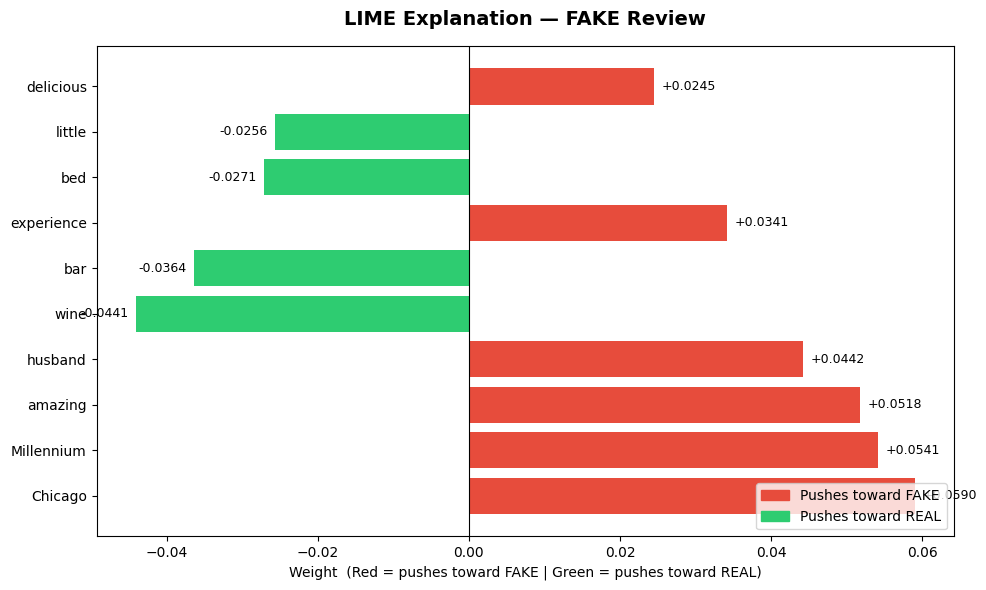

✅ Saved to outputs/lime_fake.png


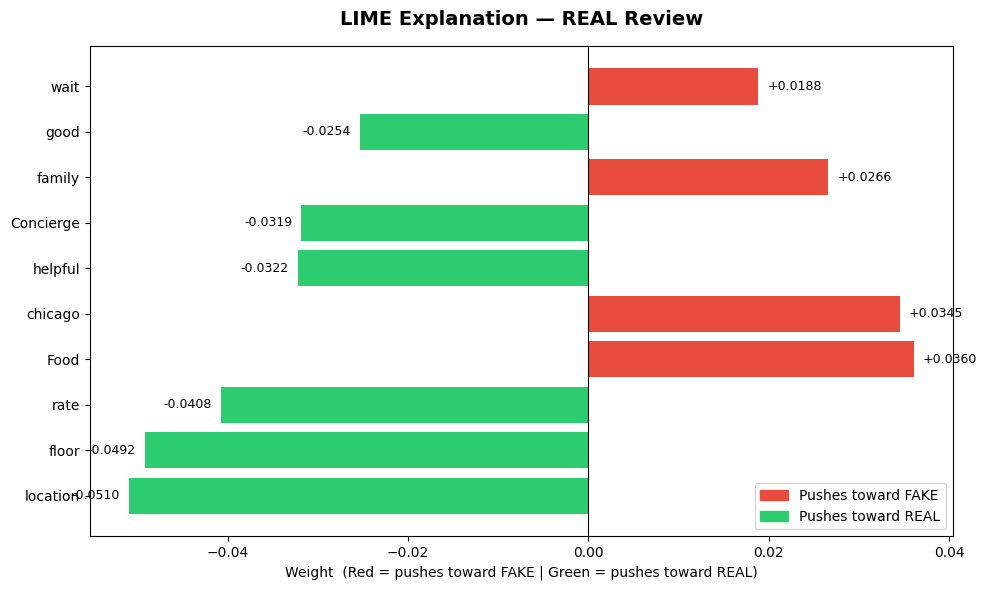

✅ Saved to outputs/lime_real.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_lime_explanation(exp, review_text, title, filename):
    words_weights = exp.as_list()
    words   = [w[0] for w in words_weights]
    weights = [w[1] for w in words_weights]
    colors  = ['#e74c3c' if w > 0 else '#2ecc71' for w in weights]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(words, weights, color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Weight  (Red = pushes toward FAKE | Green = pushes toward REAL)')

    # Add value labels
    for bar, weight in zip(bars, weights):
        ax.text(
            weight + (0.001 if weight > 0 else -0.001),
            bar.get_y() + bar.get_height()/2,
            f'{weight:+.4f}',
            va='center',
            ha='left' if weight > 0 else 'right',
            fontsize=9
        )

    fake_patch = mpatches.Patch(color='#e74c3c', label='Pushes toward FAKE')
    real_patch = mpatches.Patch(color='#2ecc71', label='Pushes toward REAL')
    ax.legend(handles=[fake_patch, real_patch], loc='lower right')

    plt.tight_layout()
    plt.savefig(f"outputs/{filename}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved to outputs/{filename}")

# Plot both
plot_lime_explanation(exp,      fake_reviews[0], "LIME Explanation — FAKE Review", "lime_fake.png")
plot_lime_explanation(exp_real, real_reviews[0], "LIME Explanation — REAL Review", "lime_real.png")

In [6]:
import shutil, os

drive_outputs = '/content/drive/MyDrive/fake-review-detector/outputs/'
os.makedirs(drive_outputs, exist_ok=True)

for f in ['lime_fake.png', 'lime_real.png']:
    shutil.copy(f"outputs/{f}", drive_outputs + f)

print("✅ LIME visualizations saved to Google Drive!")

✅ LIME visualizations saved to Google Drive!
